# Jax-gcm analisis

Ce notebook décortique le code Jax-Gcm, adapté par Tim Whittaker. Je me suis assuré d'identifier la branche précise, lister les prérequis du code et d'analyser les forçages et les filtres. 

### Section 0) Environment and reproducibility

In [1]:
# Bon environnement?
import sys
print(sys.executable)

/home/gmathieu/venvs/jcm-gpu/bin/python


In [2]:
# packages versions
import jax, xarray, numpy

print("JAX:", jax.__version__)
print("xarray:", xarray.__version__)
print("numpy:", numpy.__version__)

JAX: 0.7.2
xarray: 2025.12.0+computecanada
numpy: 2.3.3


In [3]:
#Tim's scripts imports
from pathlib import Path

BASE = Path("/home/gmathieu/work/02_analysis/jax_gcm/full_physics")
SCRIPTS = BASE / "scripts"
OUTDIR = BASE / "understand_code" / "test_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

RUN_SCRIPT  = SCRIPTS / "run_jcm_era5.py"
EVAL_SCRIPT = SCRIPTS / "eval.py"

JCM_OUT = OUTDIR / "jcm_test_30d.nc"

print("Run script:", RUN_SCRIPT)
print("Eval script:", EVAL_SCRIPT)
print("Output file:", JCM_OUT)

assert RUN_SCRIPT.exists(), f"Missing: {RUN_SCRIPT}"
assert EVAL_SCRIPT.exists(), f"Missing: {EVAL_SCRIPT}"

Run script: /home/gmathieu/work/02_analysis/jax_gcm/full_physics/scripts/run_jcm_era5.py
Eval script: /home/gmathieu/work/02_analysis/jax_gcm/full_physics/scripts/eval.py
Output file: /home/gmathieu/work/02_analysis/jax_gcm/full_physics/understand_code/test_outputs/jcm_test_30d.nc


In [4]:
# Git repo
import subprocess
subprocess.run(["git","rev-parse","HEAD"])
subprocess.run(["git","branch","--show-current"])

bbfdc68a463af03bbde27a470dd79c2eff9a4873
main


CompletedProcess(args=['git', 'branch', '--show-current'], returncode=0)

This notebook documents experiments performed with the JAX-GCM model.

All experiments were run using the environment shown above.
Recording the git commit ensures that the exact model version can be reproduced.

In [5]:
# Git info (repo root = à ajuster si nécessaire)
try:
    print("Git HEAD:", subprocess.check_output(["git","rev-parse","HEAD"], text=True).strip())
    print("Git branch:", subprocess.check_output(["git","rev-parse","--abbrev-ref","HEAD"], text=True).strip())
    s = subprocess.check_output(["git","status","--porcelain"], text=True).strip()
    print("Git status:", "clean" if s=="" else "DIRTY (uncommitted changes)")
except Exception as e:
    print("Git info not available here:", e)

Git HEAD: bbfdc68a463af03bbde27a470dd79c2eff9a4873
Git branch: main
Git status: DIRTY (uncommitted changes)


### Section 1) Overview of the JCM ERA5 simulation pipeline

The simulation workflow consists of two main scripts:

run_jcm_era5.py
    Runs a JCM climate simulation initialized from ERA5 reanalysis data.

eval.py
    Evaluates the simulation by comparing the model output with ERA5.

The workflow is therefore:

ERA5 reanalysis

        ↓
initial state interpolation

        ↓
JCM model integration

        ↓
model output (NetCDF)

        ↓
evaluation and comparison with ERA5

In [6]:
# run de 30j ici 

### Section 2) Understanding the model grid

Resolution Speedy T30

In [7]:
#La grille utilisée est celle de speedy (48, 96, 8)
from jcm.physics.speedy.speedy_coords import get_speedy_coords

coords = get_speedy_coords()

coords

W0309 14:20:10.352597  899997 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 80GB HBM3 MIG 2g.20gb. Using default config.
W0309 14:20:10.459707  899997 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 80GB HBM3 MIG 2g.20gb. Using default config.


CoordinateSystem(horizontal=Grid(longitude_wavenumbers=32, total_wavenumbers=33, longitude_nodes=96, latitude_nodes=48, latitude_spacing='gauss', longitude_offset=0.0, radius=6371220.0, spherical_harmonics_impl=<class 'dinosaur.spherical_harmonic.RealSphericalHarmonics'>, spmd_mesh=None), vertical=SigmaCoordinates(boundaries=array([0.  , 0.05, 0.14, 0.26, 0.42, 0.6 , 0.77, 0.9 , 1.  ],
      dtype=float32)), spmd_mesh=None, dycore_partition_spec=PartitionSpec('z', 'x', 'y'), physics_partition_spec=PartitionSpec(None, ('x', 'z'), 'y'))

In [8]:
print("Latitude shape =", coords.horizontal.latitudes.shape)
print("Longitude shape =", coords.horizontal.longitudes.shape)
print("Vertical shape =", coords.vertical.centers.shape)

Latitude shape = (48,)
Longitude shape = (96,)
Vertical shape = (8,)


In [9]:
import numpy as np

lats = coords.horizontal.latitudes * 180/np.pi
lons = coords.horizontal.longitudes * 180/np.pi

print(lats.min(), lats.max())
print(lons.min(), lons.max())

-87.15909455586285 87.15909455586285
0.0 356.25


The model does not include grid points exactly at the poles.

Instead, the latitude grid is defined using a Gaussian grid
(Gauss–Legendre quadrature). This type of grid improves numerical
accuracy for spherical harmonic transforms used in spectral
atmospheric models.

As a result, the first latitude is approximately −87.16° rather than −90°.

Text(0.5, 1.0, 'Gaussian latitude grid')

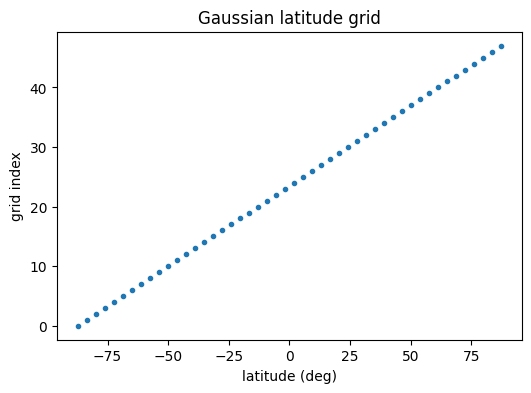

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(lats, np.arange(len(lats)), ".")

plt.xlabel("latitude (deg)")
plt.ylabel("grid index")
plt.title("Gaussian latitude grid")

Text(0, 0.5, 'degrees')

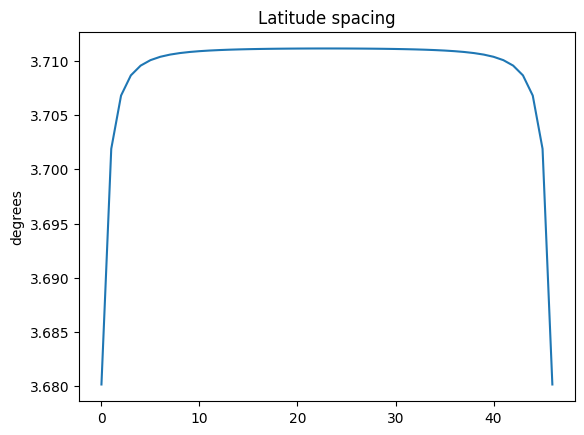

In [11]:
spacing = np.diff(lats)

plt.plot(spacing)
plt.title("Latitude spacing")
plt.ylabel("degrees")

Text(0, 0.5, 'latitude')

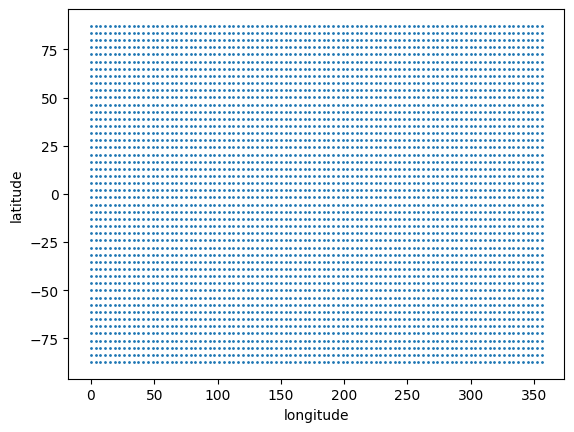

In [12]:
lon2, lat2 = np.meshgrid(lons, lats)

plt.scatter(lon2, lat2, s=1)
plt.xlabel("longitude")
plt.ylabel("latitude")

The model uses a horizontal grid of 96 longitudes and 48 latitudes.

Longitude spacing is uniform (~3.75°).

Latitude uses a Gaussian grid, which is typical for spectral atmospheric models.
Gaussian grids improve numerical accuracy for spherical harmonic transforms.

### Section 3) Vertical coordinate system (sigma levels)

The sigma vertical coordinate is defined as

σ = p / ps

where p is pressure and ps is surface pressure.

Because the coordinate is defined relative to surface pressure,
the exact pressure of each level varies spatially depending on ps.

The values computed here are therefore only an approximation.

p ≈ σ × 1013.25 hPa

which corresponds to mean sea-level pressure.

In [13]:
sigma = coords.vertical.centers
pressure = sigma * 1013.25 #hPa, 

In [14]:
print("APPROX CONVERSION SIGMA/PRESSION")
for i in range(len(sigma)):
    print("sigma =",f"{round(sigma[i], 3): .3f}", "-->", "pression =",f"{round(pressure[i], 2): .3f}", "hPa")


APPROX CONVERSION SIGMA/PRESSION
sigma =  0.025 --> pression =  25.330 hPa
sigma =  0.095 --> pression =  96.260 hPa
sigma =  0.200 --> pression =  202.650 hPa
sigma =  0.340 --> pression =  344.500 hPa
sigma =  0.510 --> pression =  516.760 hPa
sigma =  0.685 --> pression =  694.080 hPa
sigma =  0.835 --> pression =  846.060 hPa
sigma =  0.950 --> pression =  962.590 hPa


The sigma level σ ≈ 0.835 corresponds approximately to the
850 hPa pressure level used in many atmospheric diagnostics.

This is the level used for evaluation in eval.py.

Text(0.5, 1.0, 'Model vertical levels')

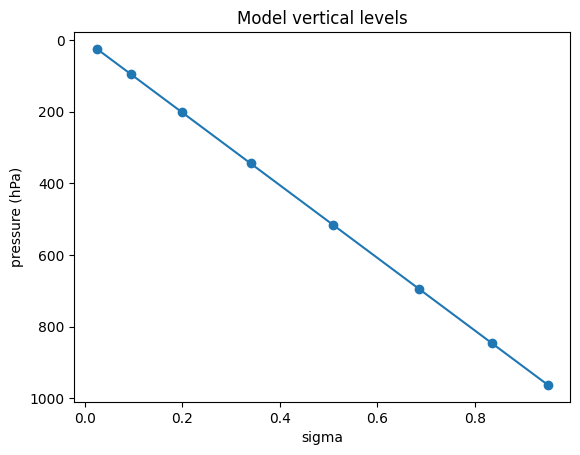

In [15]:
import matplotlib.pyplot as plt

plt.plot(sigma, pressure, "o-")
plt.gca().invert_yaxis()
plt.xlabel("sigma")
plt.ylabel("pressure (hPa)")
plt.title("Model vertical levels")

The JCM model uses a sigma vertical coordinate system:

σ = p / ps

where p is pressure and ps is surface pressure.

The model has 8 vertical levels ranging from σ ≈ 0.95 (near the surface)
to σ ≈ 0.025 (upper atmosphere).

These correspond approximately to pressure levels from ~960 hPa to ~25 hPa.

### Section 4) Model forcing

In [11]:
from importlib import resources
from jcm.terrain import TerrainData
from jcm.forcing import ForcingData

data_dir = resources.files("jcm.data.bc.t30.clim")
data_dir

MultiplexedPath('/home/gmathieu/src/jax-gcm-era5-example/jcm/data/bc/t30/clim')

# Terrain

In [12]:
#Ouverture des fichiers
import xarray as xr

terrain = xr.open_dataset(data_dir / "terrain.nc")
terrain

<xarray.Dataset> Size: 38kB
Dimensions:  (lon: 96, lat: 48)
Coordinates:
  * lon      (lon) float64 768B 0.0 3.75 7.5 11.25 ... 345.0 348.8 352.5 356.2
  * lat      (lat) float64 384B -87.16 -83.48 -79.78 ... 79.78 83.48 87.16
    lev      float64 8B ...
Data variables:
    lsm      (lon, lat) float32 18kB ...
    orog     (lon, lat) float32 18kB ...
Attributes:
    CDI:          Climate Data Interface version 1.7.1 (http://mpimet.mpg.de/...
    CDO:          Climate Data Operators version 1.7.1 (http://mpimet.mpg.de/...
    grid_type:    gaussian
    history:      Sun Apr 21 21:26:01 2019: cdo -f nc import_binary stl.ctl s...
    Conventions:  CF-1.5

In [13]:
for var in terrain.data_vars:
    v = terrain[var]
    print(var, float(v.min()), float(v.max()))

lsm 0.0 1.0
orog -8.267309188842773 5016.8671875


The terrain dataset defines the lower boundary of the atmosphere.

It contains:

- lsm (land-sea mask):
    Indicates whether a grid cell corresponds to land or ocean.

- orog (orography):
    Surface elevation of the terrain.

These variables influence surface fluxes, atmospheric circulation,
and surface pressure distribution.

# Forcing

In [14]:
# These are the forcing used: 
forcing = xr.open_dataset(data_dir / "forcing.nc")
for var in forcing.data_vars:
    v = forcing[var]
    print(var, float(v.min()), float(v.max()))

stl 211.56793212890625 314.65716552734375
icec 0.0 1.0
sst 236.63690185546875 307.2687683105469
alb 0.06999993324279785 0.4834859371185303
soilw_am 0.0 1.0
snowc 0.0 166.66668701171875


The model uses prescribed external forcing fields to represent
surface conditions.

These variables include:

- sst (sea surface temperature): Controls heat and moisture exchange between the ocean and atmosphere.

- icec (sea ice concentration): Represents the fraction of ocean covered by sea ice.

- stl (soil temperature): Influences surface heat fluxes over land.

- soilw_am (soil moisture): Affects evaporation and land-atmosphere interactions.

- snowc (snow cover): Influences surface albedo and radiation balance.

- alb (surface albedo): Determines the fraction of incoming solar radiation that is reflected.

These forcing fields represent boundary conditions and are not
dynamically simulated by the model.

In [15]:
for i,t in enumerate(forcing.time.values):
    print(i, t)

PLOT_MONTH = 6 #Choose the month for graphs (0 = jan)

0 1981-01-01T00:00:00.000000000
1 1981-02-01T00:00:00.000000000
2 1981-03-01T00:00:00.000000000
3 1981-04-01T00:00:00.000000000
4 1981-05-01T00:00:00.000000000
5 1981-06-01T00:00:00.000000000
6 1981-07-01T00:00:00.000000000
7 1981-08-01T00:00:00.000000000
8 1981-09-01T00:00:00.000000000
9 1981-10-01T00:00:00.000000000
10 1981-11-01T00:00:00.000000000
11 1981-12-01T00:00:00.000000000


It seems like the forcing is injected every day in the model (daily interpolation seen in `forcing.py`), but the values change only every 1st of the month in here. This model is therefor supposed to be used with a time resolution (time stamps) of maximum one day. 

The external forcing is used directly in the surface flux parameterization.

In `surface_flux.py`, the forcing fields (sea surface temperature, soil temperature,
and soil moisture) are used to compute:

- sensible heat flux
- evaporation
- longwave emission
- net surface heat flux
- near-surface temperature

These fluxes are then converted into atmospheric tendencies for temperature,
humidity, and momentum in the lowest model level.

Importantly, `get_surface_fluxes(...)` does not perform any time interpolation itself.
It assumes that the forcing passed to the function already corresponds to the current
model time. There is a function in `interpolate.py` called `interpolate_to_daily` that does a linear interpoaltion to transform the monthly forcing to a daily one (365d).

This implies that daily output is a natural choice for long climate runs,
since the prescribed forcing itself evolves on a daily timescale.


TERRAIN (terrain.nc)
Dataset dims: {'lon': 96, 'lat': 48}
Variables: ['lsm', 'orog']

----------------------------------------------------------------------------------------
[01] lsm
  dims: ('lon', 'lat')
  sizes: {'lon': 96, 'lat': 48}
  dtype: float32
  attrs: {'long_name': 'land-sea mask [0-1]', 'units': '1'}
  stats: min=0  max=1  mean=0.3354


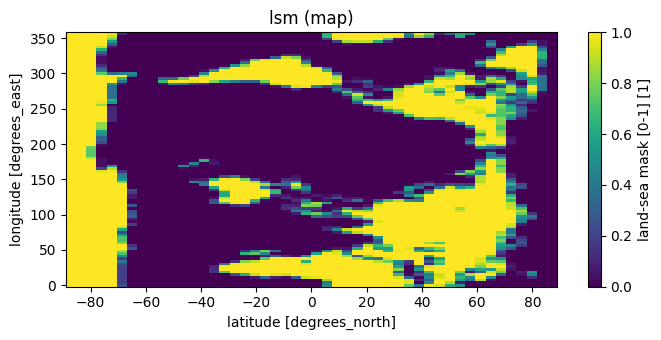

----------------------------------------------------------------------------------------
[02] orog
  dims: ('lon', 'lat')
  sizes: {'lon': 96, 'lat': 48}
  dtype: float32
  attrs: {'long_name': 'orographic height [m]', 'units': '1'}
  stats: min=-8.267  max=5017  mean=361.8


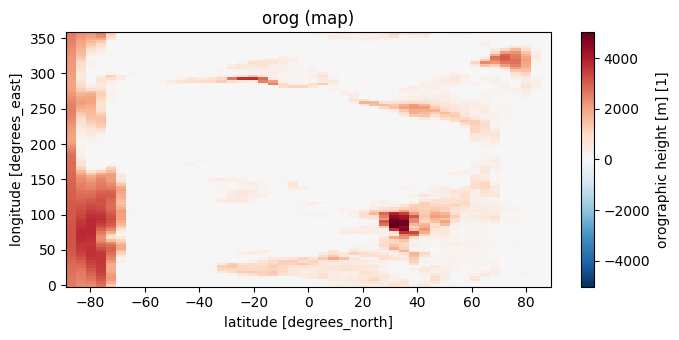


Done.


FORCING (forcing.nc)
Dataset dims: {'lon': 96, 'lat': 48, 'time': 12}
time: 1981-01-01T00:00:00.000000000 → 1981-12-01T00:00:00.000000000 (n=12)
Variables: ['stl', 'icec', 'sst', 'alb', 'soilw_am', 'snowc']

----------------------------------------------------------------------------------------
[01] stl
  dims: ('lon', 'lat', 'time')
  sizes: {'lon': 96, 'lat': 48, 'time': 12}
  dtype: float32
  attrs: {'long_name': 'land-sfc. temp (top-layer) [degK]', 'units': '1'}
  stats: min=211.6  max=314.7  mean=271.5


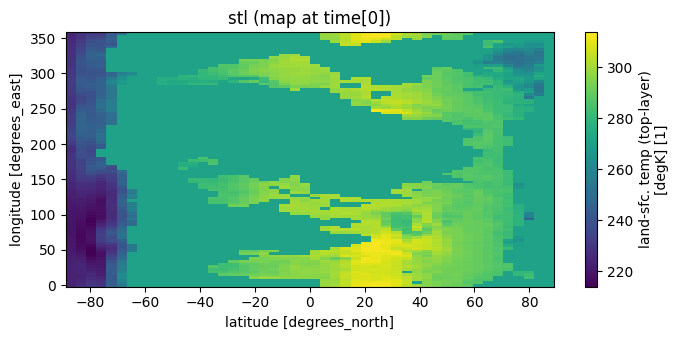

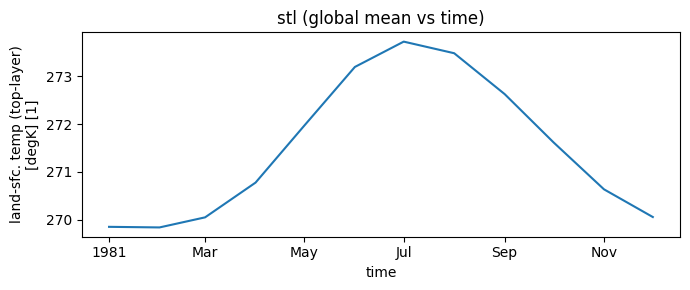

----------------------------------------------------------------------------------------
[02] icec
  dims: ('lon', 'lat', 'time')
  sizes: {'lon': 96, 'lat': 48, 'time': 12}
  dtype: float32
  attrs: {'long_name': 'sea-ice concentration [0-1]', 'units': '1'}
  stats: min=0  max=1  mean=0.1306


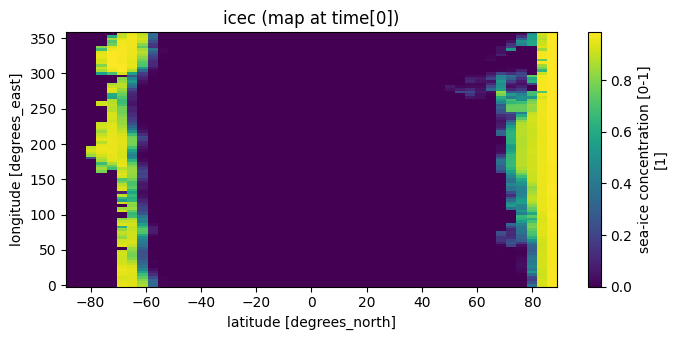

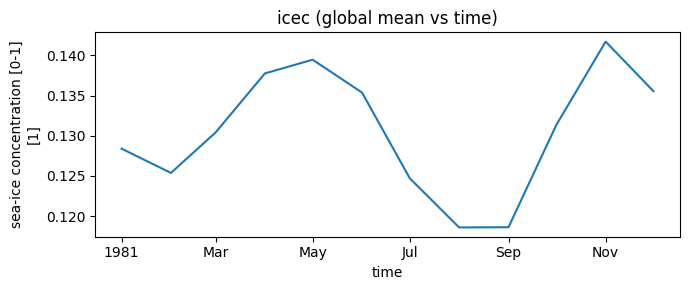

----------------------------------------------------------------------------------------
[03] sst
  dims: ('lon', 'lat', 'time')
  sizes: {'lon': 96, 'lat': 48, 'time': 12}
  dtype: float32
  attrs: {'long_name': 'sea-sfc. temperature [degK]', 'units': '1'}
  stats: min=236.6  max=307.3  mean=284.4


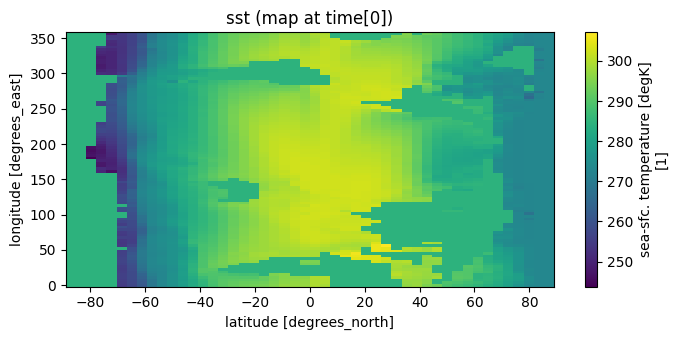

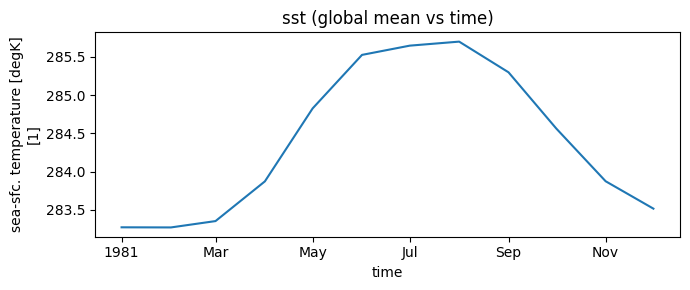

----------------------------------------------------------------------------------------
[04] alb
  dims: ('lon', 'lat')
  sizes: {'lon': 96, 'lat': 48}
  dtype: float32
  attrs: {'long_name': 'annual-mean albedo [0-1]', 'units': '1'}
  stats: min=0.07  max=0.4835  mean=0.1426


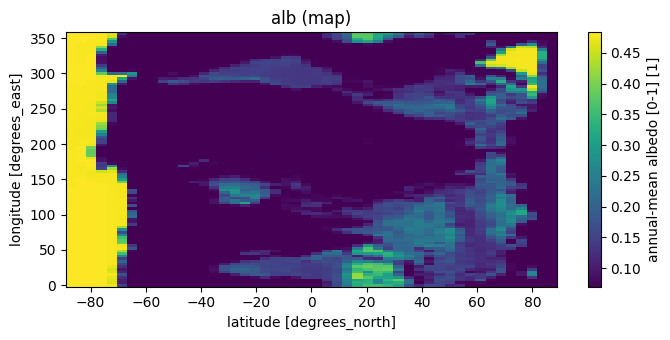

----------------------------------------------------------------------------------------
[05] soilw_am
  dims: ('lon', 'lat', 'time')
  sizes: {'lon': 96, 'lat': 48, 'time': 12}
  dtype: float32
  attrs: (none / empty)
  stats: min=0  max=1  mean=0.2498


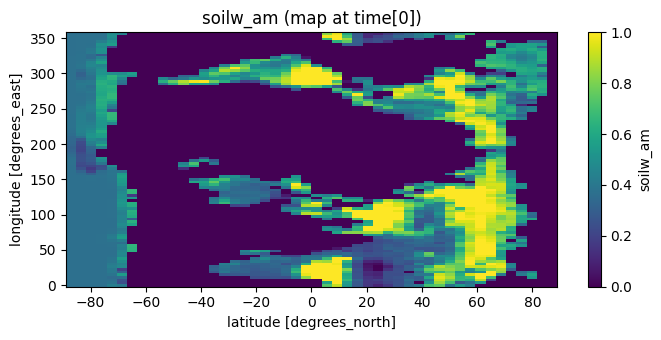

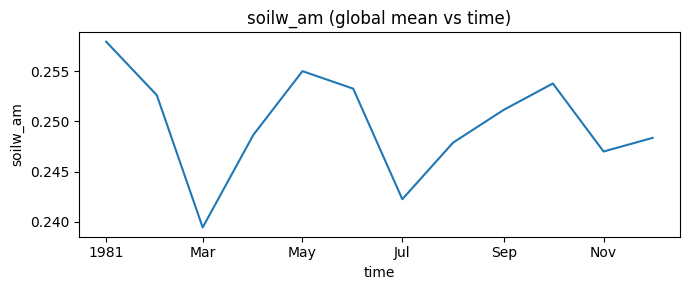

----------------------------------------------------------------------------------------
[06] snowc
  dims: ('lon', 'lat', 'time')
  sizes: {'lon': 96, 'lat': 48, 'time': 12}
  dtype: float32
  attrs: (none / empty)
  stats: min=0  max=166.7  mean=21.71


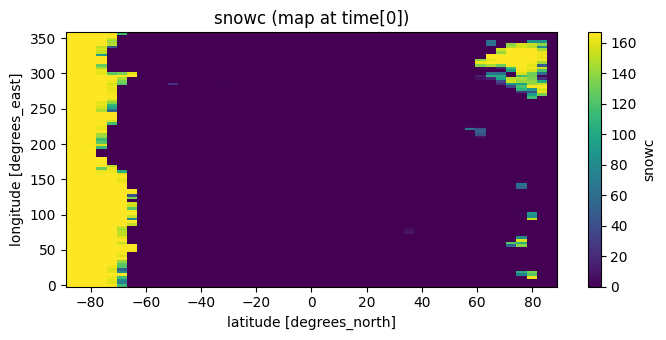

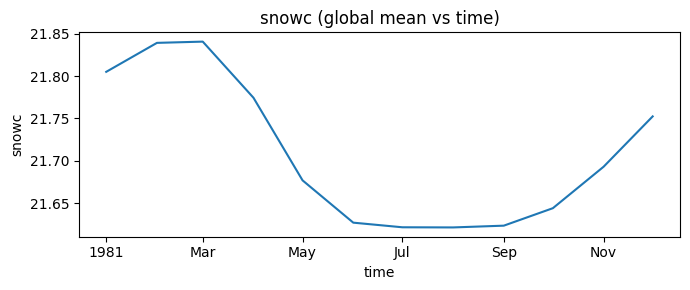


Done.



In [16]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

def _nice_attrs(da):
    """Pick a few useful attrs if present."""
    keys = ["long_name", "standard_name", "units", "description"]
    out = {k: da.attrs.get(k, None) for k in keys if da.attrs.get(k, None) is not None}
    return out

def _stats(da):
    """Robust stats with NaN handling; returns Python floats."""
    a = da.values
    a = np.asarray(a)
    return dict(
        min=float(np.nanmin(a)),
        max=float(np.nanmax(a)),
        mean=float(np.nanmean(a)),
    )

def describe_and_plot_dataset(ds, title, max_maps=12):
    """
    Print + plot each variable in an xarray Dataset.
    - 2D vars: plot 1 map
    - 3D vars with time: plot 1 map at time=0 AND a global mean seasonal cycle
    - other dims: best-effort (takes first index for extra dims)
    """
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)
    print("Dataset dims:", dict(ds.sizes))
    if "time" in ds.coords:
        try:
            print("time:", str(ds.time.values[0]), "→", str(ds.time.values[-1]), f"(n={ds.sizes.get('time','?')})")
        except Exception:
            pass
    print("Variables:", list(ds.data_vars))
    print()

    for i, name in enumerate(ds.data_vars):
        da = ds[name]
        print("-" * 88)
        print(f"[{i+1:02d}] {name}")
        print(f"  dims: {da.dims}")
        print(f"  sizes: {dict(da.sizes)}")
        print(f"  dtype: {da.dtype}")

        # attrs
        attrs = _nice_attrs(da)
        if attrs:
            print("  attrs:", attrs)
        else:
            print("  attrs: (none / empty)")

        # stats
        try:
            st = _stats(da)
            print(f"  stats: min={st['min']:.4g}  max={st['max']:.4g}  mean={st['mean']:.4g}")
        except Exception as e:
            print("  stats: (could not compute)", repr(e))

        # plotting
        # Try to keep it simple & stable: show at most max_maps maps total.
        if i >= max_maps:
            print(f"  plot: skipped (max_maps={max_maps} reached)")
            continue

        try:
            # If extra dims beyond (lon, lat, time), take first index for them.
            indexers = {}
            for d in da.dims:
                if d not in ("lon", "lat", "time"):
                    indexers[d] = 0

            da0 = da.isel(**indexers) if indexers else da

            # CASE A: (lon, lat) only
            if set(da0.dims) >= {"lon", "lat"} and "time" not in da0.dims:
                plt.figure(figsize=(7, 3.5))
                da0.plot()
                plt.title(f"{name} (map)")
                plt.tight_layout()
                plt.show()

            # CASE B: (lon, lat, time)
            elif set(da0.dims) >= {"lon", "lat", "time"}:
                # map at first time
                plt.figure(figsize=(7, 3.5))
                da_map = da0.isel(time=PLOT_MONTH)
                da_map.plot()
                plt.title(f"{name} (map at time[0])")
                plt.tight_layout()
                plt.show()

                # global mean seasonal cycle (or time series)
                try:
                    ts = da0.mean(("lon", "lat"))
                    plt.figure(figsize=(7, 3))
                    ts.plot()
                    plt.title(f"{name} (global mean vs time)")
                    plt.tight_layout()
                    plt.show()
                except Exception as e:
                    print("  plot: could not plot global-mean time series:", repr(e))

            else:
                # fallback: try plot directly
                plt.figure()
                da0.plot()
                plt.title(f"{name} (auto plot)")
                plt.tight_layout()
                plt.show()

        except Exception as e:
            print("  plot: (failed)", repr(e))

    print("\nDone.\n")


# ---- Use it on your datasets ----
describe_and_plot_dataset(terrain, title="TERRAIN (terrain.nc)", max_maps=20)
describe_and_plot_dataset(forcing, title="FORCING (forcing.nc)", max_maps=20)

### Section 5) Physics module

In [22]:
from jcm.physics.speedy.params import Parameters

In [23]:
params = Parameters.default()
params

W0309 12:58:14.554666  879539 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H100 80GB HBM3 MIG 2g.20gb. Using default config.


Parameters(convection=ConvectionParameters(psmin=Array(0.8, dtype=float32, weak_type=True), trcnv=Array(6., dtype=float32, weak_type=True), rhil=Array(0.7, dtype=float32, weak_type=True), rhbl=Array(0.9, dtype=float32, weak_type=True), entmax=Array(0.5, dtype=float32, weak_type=True), smf=Array(0.8, dtype=float32, weak_type=True)), condensation=CondensationParameters(trlsc=Array(4., dtype=float32, weak_type=True), rhlsc=Array(0.9, dtype=float32, weak_type=True), drhlsc=Array(0.1, dtype=float32, weak_type=True), rhblsc=Array(0.95, dtype=float32, weak_type=True)), shortwave_radiation=ShortwaveRadiationParameters(albcl=Array(0.43, dtype=float32, weak_type=True), albcls=Array(0.5, dtype=float32, weak_type=True), absdry=Array(0.033, dtype=float32, weak_type=True), absaer=Array(0.033, dtype=float32, weak_type=True), abswv1=Array(0.022, dtype=float32, weak_type=True), abswv2=Array(15., dtype=float32, weak_type=True), abscl1=Array(0.015, dtype=float32, weak_type=True), abscl2=Array(0.15, dtype

The atmospheric physics in JCM is based on the SPEEDY parameterization package.

The default parameter set is divided into six main components:

- convection
- large-scale condensation
- shortwave radiation
- radiative/surface constants
- surface fluxes
- vertical diffusion
- CO_2

These parameterizations represent unresolved physical processes such as
convective adjustment, radiative transfer, surface exchange, and boundary-layer mixing.

In [24]:
def print_param_block(name, block):
    print("\n" + "="*80)
    print(name.upper())
    print("="*80)
    for k, v in block.__dict__.items():
        try:
            print(f"{k:15s} : {float(v):10.5g}")
        except Exception:
            print(f"{k:15s} : {v}")

print_param_block("convection", params.convection)
print_param_block("condensation", params.condensation)
print_param_block("shortwave_radiation", params.shortwave_radiation)
print_param_block("mod_radcon", params.mod_radcon)
print_param_block("surface_flux", params.surface_flux)
print_param_block("vertical_diffusion", params.vertical_diffusion)
print_param_block("forcing", params.forcing)


CONVECTION
psmin           :        0.8
trcnv           :          6
rhil            :        0.7
rhbl            :        0.9
entmax          :        0.5
smf             :        0.8

CONDENSATION
trlsc           :          4
rhlsc           :        0.9
drhlsc          :        0.1
rhblsc          :       0.95

SHORTWAVE_RADIATION
albcl           :       0.43
albcls          :        0.5
absdry          :      0.033
absaer          :      0.033
abswv1          :      0.022
abswv2          :         15
abscl1          :      0.015
abscl2          :       0.15
ablwin          :        0.3
ablwv1          :        0.7
ablwv2          :         50
ablcl1          :         12
ablcl2          :        0.6
rhcl1           :        0.3
rhcl2           :          1
qacl            :        0.2
wpcl            :        0.2
pmaxcl          :         10
clsmax          :        0.6
clsminl         :       0.15
gse_s0          :       0.25
gse_s1          :        0.4

MOD_RADCON
albsea       

## A. Convection

The convection scheme adjusts temperature and moisture over a characteristic
timescale of about 6 hours.

It is controlled by humidity thresholds and entrainment parameters that
determine when and how strongly convection is activated.

## B. Condensation

The convection scheme adjusts temperature and moisture over a characteristic
timescale of about 6 hours.

It is controlled by humidity thresholds and entrainment parameters that
determine when and how strongly convection is activated.

## C. Shortwave radiation

The shortwave radiation scheme controls the interaction between incoming solar
radiation and the atmosphere.

It includes absorption by dry air, water vapour, aerosols, and clouds,
as well as cloud albedo effects.

## D. Radiative/surface constants

This parameter group defines radiative surface properties such as
surface emissivity and the prescribed albedo of sea, sea ice, and snow.
These values strongly influence the surface energy budget.

## E. Surface flux

Surface flux parameters control the exchange of momentum, heat, and moisture
between the atmosphere and the underlying surface.

This part of the model is especially important because it links prescribed
surface forcing (SST, soil temperature, soil moisture) to atmospheric tendencies.
It is therefore a plausible source of systematic temperature biases.

## F. Vertical diffusion

Vertical diffusion represents turbulent mixing in the boundary layer and lower atmosphere.
It redistributes heat, moisture, and momentum vertically and can strongly affect
near-surface temperature structure.

## G. CO_2

The default configuration does not include increasing CO2 forcing.
The model therefore runs with a fixed reference CO2 state (1950).

### Conclusion

The SPEEDY physics package is organized into a small number of simplified
parameterization modules.

These modules represent unresolved atmospheric processes including
convection, large-scale condensation, radiative transfer, surface exchange,
and vertical mixing.

Among these, the surface flux and radiation components appear especially
important for diagnosing the global cold bias seen in long simulations.


### Section 6) PhysicsState structure

After examining the model grid, forcing fields, and physical parameterizations,
the next step is to understand how these components are assembled into a working model.

The JCM model combines four main elements:

- the horizontal and vertical grid
- the physical parameterization package (SPEEDY physics)
- prescribed external forcing
- an initial atmospheric state

These components are combined into a `Model` object which is then integrated forward in time.

The model integration requires an initial atmospheric state.

This state includes the 3-D fields of:

- temperature
- wind components
- specific humidity
- geopotential
- surface pressure

These fields are typically initialized from ERA5 reanalysis.

The Model object combines the grid definition and the physics module.

Once the model is created, it can be integrated forward in time
using the model.run() function.

The model integrates the atmospheric state forward in time
and periodically saves snapshots of the evolving state variables.

The output can then be converted to an xarray dataset for analysis.

The JCM model integrates atmospheric dynamics and simplified physics
on a coarse global grid.

The model configuration is defined by combining:

- a spectral dynamical core
- SPEEDY physical parameterizations
- prescribed external forcing
- an initial atmospheric state

Understanding how these components interact is essential for diagnosing
systematic biases such as the global cold bias observed in long simulations.

### Section 7) Numerical filters

Atmospheric models require numerical stabilization to prevent the buildup
of small-scale numerical noise.

Spectral atmospheric models such as JCM commonly apply numerical filters
or diffusion operators to damp the smallest resolved scales.

These filters improve numerical stability but can also influence the
energy budget of the simulation.

In [31]:
params.vertical_diffusion

VerticalDiffusionParameters(trshc=Array(6., dtype=float32, weak_type=True), trvdi=Array(24., dtype=float32, weak_type=True), trvds=Array(6., dtype=float32, weak_type=True), redshc=Array(0.5, dtype=float32, weak_type=True), rhgrad=Array(0.5, dtype=float32, weak_type=True), segrad=Array(0.1, dtype=float32, weak_type=True))

The main explicit damping mechanism in the SPEEDY physics package
is the vertical diffusion scheme.

This parameterization redistributes heat, moisture, and momentum
vertically and acts as a stabilizing mechanism for the atmospheric
boundary layer.

In [33]:
print(params.vertical_diffusion.trvdi)

24.0


The vertical diffusion timescale (24 hours) indicates relatively slow
mixing in the free troposphere compared to the boundary layer.

In [34]:
for k, v in params.vertical_diffusion.__dict__.items():
    try:
        print(f"{k:10s} : {float(v):.5g}")
    except Exception:
        print(f"{k:10s} : {v}")

trshc      : 6
trvdi      : 24
trvds      : 6
redshc     : 0.5
rhgrad     : 0.5
segrad     : 0.1


Several processes in the model contribute to energy dissipation
or stabilization, including vertical diffusion, surface drag,
and radiative cooling.

These mechanisms are necessary for numerical stability but may
also influence the simulated global temperature.

### Section 8) Questions and hypothesis

Why is the model 2k too cold? 

Possible causes:
- radiation parameterization
- SST forcing